# 2. The label is the decision that matters most

**Claim under test:** you have biased historical decisions, so you apply
"bias-aware training" to stop the model learning the prejudice.

That is the standard "historical label correction" step. It answers the wrong question.
The prior question is *what are you predicting*, and in lending you usually
observe the real outcome: whether the loan was repaid.

Training on "did a human approve this" teaches the model the human's prejudice.
Training on "was it repaid" does not.

An earlier version of this notebook then asserted that no correction technique
recovers as much as choosing the right label. That was never run. It is measured
below, over 12 seeds, and it is **wrong in this generator**: reweighing the
prejudiced label lands exactly where the right label lands, and dropping the
proxies beats it. Why that happens, and why it does not generalise, is the
second half of the notebook.

- Obermeyer et al., *Dissecting racial bias in an algorithm used to manage the
  health of populations*, Science 2019. The canonical case: the algorithm
  predicted healthcare **cost** as a proxy for **need**. Less was spent on Black
  patients, so it rated them healthier. Changing the label removed the bias.
  https://www.science.org/doi/10.1126/science.aax2342
- Lakkaraju et al., *The Selective Labels Problem*, KDD 2017 - you only observe
  repayment for applicants somebody approved

**AI Act:** Article 10(2) is about data governance for the training set. The
choice of target variable is a data-governance decision and it is the one with
the largest effect here.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

RNG = np.random.default_rng(11)
N = 20000

group_b = RNG.random(N) < 0.35          # never given to any model

utilisation = RNG.beta(2, 5, N) + np.where(group_b, 0.04, 0.0)
inquiries   = RNG.poisson(np.where(group_b, 1.5, 1.2), N)
tenure      = RNG.gamma(3, 1.4, N) * np.where(group_b, 0.9, 1.0)
postcode    = RNG.normal(np.where(group_b, -1.1, 0.5), 1.0, N)
carrier     = RNG.binomial(1, np.where(group_b, 0.62, 0.24), N)
occupation  = RNG.binomial(1, np.where(group_b, 0.58, 0.25), N)

X = pd.DataFrame({'utilisation': utilisation, 'inquiries': inquiries,
                  'tenure_years': tenure, 'postcode_income_z': postcode,
                  'phone_carrier': carrier, 'occupation_cat': occupation})

## Two different labels

`repaid` depends only on genuine risk signals. `approved` depends on the same
signals **plus a penalty on group B itself** - that is the historical prejudice.

`repaid` is observed for everyone here because this is a simulation. In reality
you only see it for applicants who were approved, which is the selective labels
problem, and model B below is trained under that restriction.

In [2]:
risk = -3.2 * utilisation - 0.25 * inquiries + 0.10 * tenure + 0.05 * postcode + 1.6

repaid   = RNG.binomial(1, 1 / (1 + np.exp(-risk)))                 # the real outcome
approved = RNG.binomial(1, 1 / (1 + np.exp(-(risk - 1.4 * group_b)))).astype(bool)

a, b = ~group_b, group_b
print('GROUND TRUTH')
print(f'  true repayment rate   A={repaid[a].mean():.1%}  B={repaid[b].mean():.1%}'
      f'   ratio={repaid[b].mean() / repaid[a].mean():.2f}')
print(f'  human approval rate   A={approved[a].mean():.1%}  B={approved[b].mean():.1%}'
      f'   ratio={approved[b].mean() / approved[a].mean():.2f}')
print(f'\n  repayment is observable for {approved.sum()} of {N} applicants '
      f'({approved.mean():.0%}). The rest were never approved.')

GROUND TRUTH
  true repayment rate   A=67.1%  B=61.9%   ratio=0.92
  human approval rate   A=67.7%  B=30.6%   ratio=0.45

  repayment is observable for 10891 of 20000 applicants (54%). The rest were never approved.


The gap the humans created (ratio 0.45) is far larger than any real difference in
repayment (0.92). That gap is what a model trained on `approved` will learn.

In [3]:
from sklearn.model_selection import train_test_split

# Held-out evaluation. The first version of this notebook trained and scored on
# the same 20,000 rows, which put model C above the ceiling of its own
# generator: the true risk score only reaches AUC 0.676 on a fresh draw.
idx = np.arange(N)
tr, te = train_test_split(idx, test_size=0.5, random_state=0)

models = {
    'A   label = human decision':           (X.iloc[tr], approved[tr]),
    'B   label = repayment, approved only': (X.iloc[tr][approved[tr]], repaid[tr][approved[tr]]),
    'C   label = repayment, everyone':      (X.iloc[tr], repaid[tr]),
}
accept_rate = approved.mean()
a_te, b_te = a[te], b[te]

print(f'ceiling: the true risk score scores AUC '
      f'{roc_auc_score(repaid[te], risk[te]):.3f} on held-out data\n')

for name, (X_train, y_train) in models.items():
    model = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
    p = model.predict_proba(X.iloc[te])[:, 1]
    decision = p >= np.quantile(p, 1 - accept_rate)
    dir_ = decision[b_te].mean() / decision[a_te].mean()
    print(f'{name}')
    print(f'    accept rate  A={decision[a_te].mean():.1%}  B={decision[b_te].mean():.1%}   '
          f'DIR={dir_:.2f}  {"FAILS four-fifths" if dir_ < 0.8 else "passes four-fifths"}')
    print(f'    AUC against true repayment (held out) = {roc_auc_score(repaid[te], p):.3f}\n')


ceiling: the true risk score scores AUC 0.667 on held-out data



A   label = human decision
    accept rate  A=71.1%  B=24.1%   DIR=0.34  FAILS four-fifths
    AUC against true repayment (held out) = 0.627



B   label = repayment, approved only
    accept rate  A=58.6%  B=46.9%   DIR=0.80  passes four-fifths
    AUC against true repayment (held out) = 0.622



C   label = repayment, everyone
    accept rate  A=59.6%  B=45.0%   DIR=0.75  FAILS four-fifths
    AUC against true repayment (held out) = 0.636



## Is any of that repeatable?

One dataset, one split. The DIR gap is large and the AUC gaps are small, so the
two need checking separately before either is reported.

In [4]:
from sklearn.model_selection import train_test_split

def one_run(seed):
    R = np.random.default_rng(seed)
    gb = R.random(N) < 0.35
    u = R.beta(2, 5, N) + np.where(gb, 0.04, 0.0)
    i = R.poisson(np.where(gb, 1.5, 1.2), N)
    t = R.gamma(3, 1.4, N) * np.where(gb, 0.9, 1.0)
    po = R.normal(np.where(gb, -1.1, 0.5), 1.0, N)
    ca = R.binomial(1, np.where(gb, 0.62, 0.24), N)
    oc = R.binomial(1, np.where(gb, 0.58, 0.25), N)
    Xs = pd.DataFrame({'utilisation': u, 'inquiries': i, 'tenure_years': t,
                       'postcode_income_z': po, 'phone_carrier': ca, 'occupation_cat': oc})
    rk = -3.2 * u - 0.25 * i + 0.10 * t + 0.05 * po + 1.6
    rp = R.binomial(1, 1 / (1 + np.exp(-rk)))
    ap = R.binomial(1, 1 / (1 + np.exp(-(rk - 1.4 * gb)))).astype(bool)
    tr, te = train_test_split(np.arange(N), test_size=0.5, random_state=0)
    out = {}
    for nm, (Xt, yt) in {'A': (Xs.iloc[tr], ap[tr]),
                         'B': (Xs.iloc[tr][ap[tr]], rp[tr][ap[tr]]),
                         'C': (Xs.iloc[tr], rp[tr])}.items():
        m = HistGradientBoostingClassifier(random_state=0).fit(Xt, yt)
        pr = m.predict_proba(Xs.iloc[te])[:, 1]
        d = pr >= np.quantile(pr, 1 - ap.mean())
        out[nm + '_auc'] = roc_auc_score(rp[te], pr)
        out[nm + '_dir'] = d[gb[te]].mean() / d[~gb[te]].mean()
    return out


runs = pd.DataFrame([one_run(s) for s in range(12)])
print(f"{'':<8}{'AUC':>8}{'sd':>7}{'DIR':>8}{'sd':>7}")
for m in 'ABC':
    print(f'{m:<8}{runs[m + "_auc"].mean():>8.3f}{runs[m + "_auc"].std():>7.3f}'
          f'{runs[m + "_dir"].mean():>8.2f}{runs[m + "_dir"].std():>7.3f}')
print(f'\nC beats A on AUC in {(runs.C_auc > runs.A_auc).sum()}/12 seeds')
print(f'A worse than C on DIR in {(runs.A_dir < runs.C_dir).sum()}/12 seeds')
print(f'A vs B on AUC: mean difference {runs.A_auc.mean() - runs.B_auc.mean():+.3f}')

             AUC     sd     DIR     sd
A          0.635  0.006    0.35  0.012
B          0.634  0.006    0.73  0.046
C          0.647  0.005    0.71  0.040

C beats A on AUC in 12/12 seeds
A worse than C on DIR in 12/12 seeds
A vs B on AUC: mean difference +0.002


## Read the numbers

The ceiling matters: the true risk score, the best anything could do, reaches
about 0.67 on held-out data. Nothing below should beat it, and an earlier version
of this notebook produced a model that did, because it was scored on its own
training rows.

**The fairness effect is large and unanimous.** DIR 0.35 for the human-decision
label against about 0.72 for either repayment label, in 12 seeds out of 12. That
is the difference between a system that would be struck down and one that merely
fails a screening rule.

**The accuracy effect is small, and half of it does not exist.** C beats A by
0.012 AUC - consistent, 12 seeds out of 12, but 0.012. And **A and B are
indistinguishable**. That matters, because B is the model you can actually build:
in reality you only observe repayment for people somebody approved. So switching
to the right label buys you an enormous fairness improvement and, realistically,
no accuracy at all.

An earlier version of this notebook claimed the human-decision label was "worse
on both axes at once" with a 0.07 accuracy gap. That gap was an artefact of
scoring on training data. The fairness half of the claim holds; the accuracy half
does not, once B rather than C is the comparison.

**All three still fail four-fifths**, or sit on the line. Group B does repay
slightly less often, and thresholding turns a small difference in rates into a
large one in selection. Changing the label moves DIR from 0.35 to about 0.72 and
stops there. Necessary, not sufficient, and the remainder is a decision about the
threshold rather than about the data.

## Can you correct the wrong label instead?

The claim above says no. Nothing tested it. Four standard moves, all applied to
the prejudiced label A, all on the same held-out split, 12 seeds:

- **per-group thresholds** - post-processing, needs the group at decision time
- **reweighing** - Kamiran & Calders 2012, weight each (group, label) cell by
  `P(group)P(label) / P(group, label)`, needs the group at training time
- **drop the proxies** - `postcode_income_z`, `phone_carrier`, `occupation_cat`


In [5]:
from scipy.optimize import minimize

PROXIES = ['postcode_income_z', 'phone_carrier', 'occupation_cat']


def parity_penalised(Xt, yt, g, lam=8.0):
    """In-training constraint: logistic regression plus a smooth penalty on the
    difference in mean predicted score between groups. This is the third family -
    the notebook already has pre-processing (drop, reweigh) and post-processing
    (thresholds) and nothing that constrains the fit itself."""
    mu, sd = Xt.mean(0), Xt.std(0)
    Z = np.c_[np.ones(len(Xt)), (Xt - mu) / sd]

    def objective(w):
        s = Z @ w
        pr = 1 / (1 + np.exp(-s))
        nll = np.mean(np.logaddexp(0, s) - yt * s)
        return nll + lam * (pr[g].mean() - pr[~g].mean()) ** 2

    w = minimize(objective, np.zeros(Z.shape[1]), method='L-BFGS-B').x
    return lambda Xn: 1 / (1 + np.exp(-(np.c_[np.ones(len(Xn)), (Xn - mu) / sd] @ w)))


def measure(p, te_idx, repaid_s, group_s, rate, per_group=False):
    """AUC against true repayment, and DIR of the accept decision."""
    if per_group:
        d = np.zeros(len(te_idx), bool)
        for g in (False, True):
            m = group_s[te_idx] == g
            d[m] = p[m] >= np.quantile(p[m], 1 - rate)
    else:
        d = p >= np.quantile(p, 1 - rate)
    return (roc_auc_score(repaid_s[te_idx], p),
            d[group_s[te_idx]].mean() / d[~group_s[te_idx]].mean())


def corrections(seed):
    R = np.random.default_rng(seed)
    gb = R.random(N) < 0.35
    u = R.beta(2, 5, N) + np.where(gb, 0.04, 0.0)
    i = R.poisson(np.where(gb, 1.5, 1.2), N)
    t = R.gamma(3, 1.4, N) * np.where(gb, 0.9, 1.0)
    po = R.normal(np.where(gb, -1.1, 0.5), 1.0, N)
    ca = R.binomial(1, np.where(gb, 0.62, 0.24), N)
    oc = R.binomial(1, np.where(gb, 0.58, 0.25), N)
    Xs = pd.DataFrame({'utilisation': u, 'inquiries': i, 'tenure_years': t,
                       'postcode_income_z': po, 'phone_carrier': ca,
                       'occupation_cat': oc})
    rk = -3.2 * u - 0.25 * i + 0.10 * t + 0.05 * po + 1.6
    rp = R.binomial(1, 1 / (1 + np.exp(-rk)))
    ap = R.binomial(1, 1 / (1 + np.exp(-(rk - 1.4 * gb)))).astype(bool)
    tr, te = train_test_split(np.arange(N), test_size=0.5, random_state=0)
    rate = ap.mean()
    fit = lambda Xt, yt, w=None: HistGradientBoostingClassifier(
        random_state=0).fit(Xt, yt, sample_weight=w)
    out = {}

    m = fit(Xs.iloc[tr], ap[tr])
    p = m.predict_proba(Xs.iloc[te])[:, 1]
    out['A   as is'] = measure(p, te, rp, gb, rate)
    out['A + per-group thresholds'] = measure(p, te, rp, gb, rate, per_group=True)

    w = np.empty(len(tr))                                   # Kamiran & Calders
    for g in (False, True):
        for y in (False, True):
            sel = (gb[tr] == g) & (ap[tr] == y)
            w[sel] = (gb[tr] == g).mean() * (ap[tr] == y).mean() / sel.mean()
    m = fit(Xs.iloc[tr], ap[tr], w)
    out['A + reweighing'] = measure(m.predict_proba(Xs.iloc[te])[:, 1], te, rp, gb, rate)

    Xd = Xs.drop(columns=PROXIES)
    m = fit(Xd.iloc[tr], ap[tr])
    out['A   proxies dropped'] = measure(m.predict_proba(Xd.iloc[te])[:, 1], te, rp, gb, rate)

    # Same model class both ways, so the penalty is the only difference.
    for lam, nm in ((0.0, 'A   logistic, unconstrained'),
                    (8.0, 'A + parity penalty in training')):
        f = parity_penalised(Xs.values[tr], ap[tr].astype(float), gb[tr], lam)
        out[nm] = measure(f(Xs.values[te]), te, rp, gb, rate)

    m = fit(Xs.iloc[tr], rp[tr])
    out['C   right label'] = measure(m.predict_proba(Xs.iloc[te])[:, 1], te, rp, gb, rate)

    rk = -3.2 * u - 0.25 * i + 0.10 * t + 0.05 * po + 1.6      # the Bayes ranking
    out['ceiling  true risk score'] = (roc_auc_score(rp[te], rk[te]), np.nan)
    return out


corr = pd.DataFrame([corrections(s) for s in range(12)])
print(f"{'':<30}{'AUC':>7}{'sd':>7}{'DIR':>7}{'sd':>7}")
for k in corr.columns:
    au = np.array([v[0] for v in corr[k]])
    di = np.array([v[1] for v in corr[k]])
    d = '      -      -' if np.isnan(di).all() else f'{di.mean():>7.2f}{di.std():>7.3f}'
    print(f'{k:<30}{au.mean():>7.3f}{au.std():>7.3f}{d}')


                                  AUC     sd    DIR     sd
A   as is                       0.635  0.006   0.35  0.011
A + per-group thresholds        0.635  0.006   1.00  0.000
A + reweighing                  0.647  0.005   0.73  0.021
A   proxies dropped             0.651  0.006   0.77  0.014
A   logistic, unconstrained     0.649  0.006   0.33  0.014
A + parity penalty in training  0.668  0.005   0.87  0.017
C   right label                 0.647  0.005   0.71  0.039
ceiling  true risk score        0.672  0.005      -      -


### Read that table before believing the claim it replaces

Reweighing the prejudiced label reaches DIR 0.73 at AUC 0.647. The right label
reaches 0.71 at 0.647. They are the same point. Per-group thresholds reach
DIR 1.00 at no AUC cost at all. Dropping the three proxies beats the right label
on **both** axes: 0.651 and 0.77.

The in-training constraint is the strongest row in the table: **0.668 at DIR
0.87**, against 0.649 at 0.33 for the same logistic model with the penalty
switched off, and a Bayes ceiling of 0.672. Compare it to the unconstrained
logistic and not to the boosted rows - the model class differs. It gains
accuracy rather than paying for fairness, because in this world the prejudice in
label A is *noise* with respect to repayment, and a penalty that suppresses the
group signal suppresses that noise with it. Do not carry that across to a
setting where the disparity is partly real; there the same penalty costs
accuracy.

The table now covers all three families: pre-processing (reweigh, drop),
in-training (the penalty), post-processing (thresholds).

So the honest version of this notebook's claim is narrower:

> Choosing the right label is the only move here that needs no access to the
> protected attribute and no judgement about which feature is a proxy.

Reweighing and per-group thresholds both need the group membership - at training
time and at decision time respectively - which under the AI Act is exactly the
special-category data you may not be allowed to hold. Label choice needs nothing.

**And the proxy-dropping row is an artefact of this generator, not a finding.**
Look at `risk` in cell 3: `postcode` has weight 0.05, and `phone_carrier` and
`occupation_cat` have weight zero. They carry the human's penalty and no
repayment signal whatsoever, so deleting them is free by construction. That is
the opposite of notebook 1, where the proxies carry real signal, and of notebook
7, where six removals on UCI Adult cost the model real accuracy and still leave
the adversary at 0.644. Do not carry the 0.651 out of this file.

## The other half of selective labels

Model B is trained only on approved applicants, which is the training half of the
problem. There is an evaluation half, and it is worse.

A real lender cannot score B against everyone either. Repayment is observed only
for the people somebody approved, so the AUC that goes in the report is measured
on approved rows only. The simulation is the only place both numbers exist.

In [6]:
m_b = HistGradientBoostingClassifier(random_state=0).fit(
    X.iloc[tr][approved[tr]], repaid[tr][approved[tr]])
p_b = m_b.predict_proba(X.iloc[te])[:, 1]

seen = approved[te]                                  # what a lender can observe
print(f'model B scored on approved test rows only (what gets reported) = '
      f'{roc_auc_score(repaid[te][seen], p_b[seen]):.3f}   n={seen.sum()}')
print(f'model B scored on every test row (the truth)                   = '
      f'{roc_auc_score(repaid[te], p_b):.3f}   n={len(te)}')
gap = roc_auc_score(repaid[te][seen], p_b[seen]) - roc_auc_score(repaid[te], p_b)
print(f'\nthe observable number is {gap:+.3f} AUC from the truth, and no amount of\n'
      f'held-out discipline finds that, because the held-out rows are selected too')


model B scored on approved test rows only (what gets reported) = 0.604   n=5446
model B scored on every test row (the truth)                   = 0.622   n=10000

the observable number is -0.018 AUC from the truth, and no amount of
held-out discipline finds that, because the held-out rows are selected too


Here the observable number is **lower** than the truth, not higher. Approving on
the score truncates the range: among approved applicants the scores are all
high, so the model has less to discriminate between and looks worse on the
survivors than it is.

The direction is a property of the selection rule, not a rule of thumb - a
stricter rule truncates harder. What generalises is that **the number you can
measure is not the number you want**, and cross-validation cannot tell you so,
because the held-out rows were selected by the same process as the training
rows.

## What happens when you leave it running

Everything so far is one round. A deployed system is a loop: it decides, it
observes the outcome only for the people it accepted, those rows become next
year's training data, and it decides again.

Barocas, Hardt & Narayanan call this predictions affecting the training set. The
selective-labels problem above is one turn of it. Run six.

In [7]:
def cohort(R, n):
    gb = R.random(n) < 0.35
    u = R.beta(2, 5, n) + np.where(gb, 0.04, 0.0)
    i = R.poisson(np.where(gb, 1.5, 1.2), n)
    t = R.gamma(3, 1.4, n) * np.where(gb, 0.9, 1.0)
    po = R.normal(np.where(gb, -1.1, 0.5), 1.0, n)
    ca = R.binomial(1, np.where(gb, 0.62, 0.24), n)
    oc = R.binomial(1, np.where(gb, 0.58, 0.25), n)
    Xs = pd.DataFrame({'utilisation': u, 'inquiries': i, 'tenure_years': t,
                       'postcode_income_z': po, 'phone_carrier': ca,
                       'occupation_cat': oc})
    rk = -3.2 * u - 0.25 * i + 0.10 * t + 0.05 * po + 1.6
    return Xs, R.binomial(1, 1 / (1 + np.exp(-rk))), gb, rk


R = np.random.default_rng(21)
X_audit, y_audit, g_audit, _ = cohort(R, 8000)          # a fixed yardstick

# Round 0 is the historical file: the human decided, and repayment is on record
# only for the people the human approved.
X0, y0, g0, rk0 = cohort(R, 6000)
approved0 = R.binomial(1, 1 / (1 + np.exp(-(rk0 - 1.4 * g0)))).astype(bool)
pool_X, pool_y = X0[approved0], y0[approved0]
pool_g = g0[approved0]

print(f"{'round':<7}{'accept A':>10}{'accept B':>10}{'DIR':>7}"
      f"{'B share of pool':>18}{'AUC on audit':>14}")
print(f"{'0':<7}{'':>10}{'':>10}{'':>7}{pool_g.mean():>18.1%}{'':>14}")

for rnd in range(1, 7):
    model = HistGradientBoostingClassifier(random_state=0).fit(pool_X, pool_y)
    Xn, yn, gn, _ = cohort(R, 3000)
    p = model.predict_proba(Xn)[:, 1]
    accept = p >= np.quantile(p, 1 - 0.55)
    dir_ = accept[gn].mean() / accept[~gn].mean()

    # only the accepted are ever observed
    pool_X = pd.concat([pool_X, Xn[accept]], ignore_index=True)
    pool_y = np.r_[pool_y, yn[accept]]
    pool_g = np.r_[pool_g, gn[accept]]

    auc = roc_auc_score(y_audit, model.predict_proba(X_audit)[:, 1])
    print(f'{rnd:<7}{accept[~gn].mean():>10.1%}{accept[gn].mean():>10.1%}'
          f'{dir_:>7.2f}{pool_g.mean():>18.1%}{auc:>14.3f}')


round    accept A  accept B    DIR   B share of pool  AUC on audit
0                                              19.4%              


1           61.4%     43.6%   0.71             22.5%         0.623


2           61.3%     43.1%   0.70             23.6%         0.637


3           62.0%     41.7%   0.67             24.1%         0.645


4           61.5%     42.2%   0.69             24.4%         0.650


5           61.9%     41.0%   0.66             24.4%         0.651


6           63.0%     39.3%   0.62             24.4%         0.665


Read the columns against each other, because they disagree.

**The model is fairer than the human it replaced, and gets less fair every
round.** Round 1 opens at DIR 0.71 - well above the human baseline of 0.45 in
cell 3 - and drifts to **0.62** by round 6. Acceptance for group A holds at 61-63%
throughout while acceptance for group B falls from 43.6% to 39.3%. Nobody changed
the rule. The rule is retrained on data it selected.

**Group B's share of the training pool rises**, 19.4% to 24.4%, which is the
opposite of the obvious prediction and worth saying plainly. The starting pool is
the human's approvals, and the human was far more prejudiced than the model, so B
recovers ground at first and then plateaus. Pool composition is not the mechanism
here; the mechanism is that the model only ever learns about the applicants it
accepted, and it accepts the ones it already scores well.

**And accuracy improves the whole time.** The audit AUC rises 0.623 to 0.665 on a
fixed yardstick that is drawn fresh each time. The metric the ML team watches goes
up in every round in which the disparity gets worse.

Two things to take from it. A fairness audit run once tells you about one round;
the quantity that matters is the trend, and no compliance checklist asks for it.
And the model's own performance metric is not a warning system - here it points
the other way.


## The picture


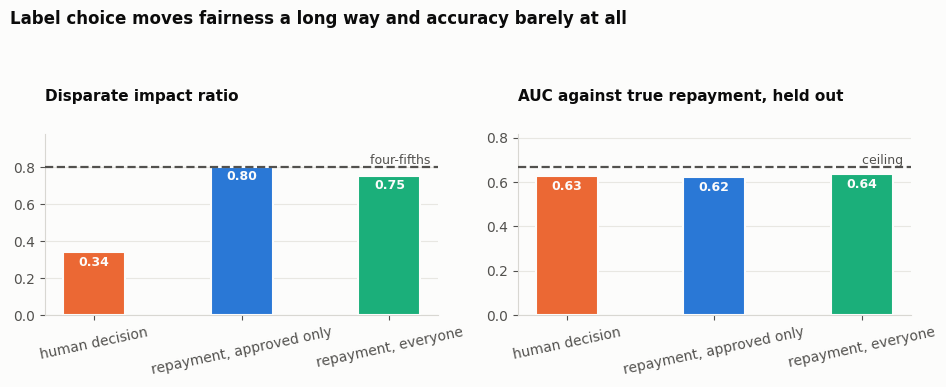

In [8]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

# Held out, like cell 5. The first version of this chart scored on all 20,000
# rows and put model C at 0.73, above the 0.667 ceiling of its own generator.
ceiling = roc_auc_score(repaid[te], risk[te])
names, dirs, aucs = [], [], []
for name, (X_train, y_train) in models.items():
    m = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
    p = m.predict_proba(X.iloc[te])[:, 1]
    d = p >= np.quantile(p, 1 - accept_rate)
    names.append(name.split('label = ')[1])
    dirs.append(d[b_te].mean() / d[a_te].mean())
    aucs.append(roc_auc_score(repaid[te], p))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
for ax, vals, title, ref, reflab in (
        (axes[0], dirs, 'Disparate impact ratio', 0.8, 'four-fifths'),
        (axes[1], aucs, 'AUC against true repayment, held out', ceiling, 'ceiling')):
    bars = ax.bar(names, vals, color=[ORANGE, BLUE, AQUA], width=0.42, zorder=3, edgecolor=SURFACE, lw=1.5)
    if ref:
        ax.axhline(ref, color=MUTED, lw=1.6, ls='--', zorder=4)
        ax.text(0.99, ref, reflab + ' ', color=MUTED, fontsize=9, va='bottom', ha='right',
                transform=ax.get_yaxis_transform())
    # Labels sit inside the bar: both reference lines run close to a bar top,
    # and a label above the bar collides with the line.
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v - 0.018, f'{v:.2f}',
                ha='center', va='top', fontsize=9, color=SURFACE, fontweight='bold')
    tidy(ax, xgrid=False)
    ax.set_title(title, loc='left', pad=24)
    ax.tick_params(axis='x', labelrotation=12)
    ax.set_ylim(0, max(vals + ([ref] if ref else [])) * 1.22)
fig.suptitle('Label choice moves fairness a long way and accuracy barely at all',
             x=0.012, ha='left', fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('../figures/02_label_choice.png', dpi=150, bbox_inches='tight')
plt.show()